In [51]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [52]:
def filter_boxes_in_polygon(points: np.ndarray, polygon: np.ndarray) -> list[int]:
    """
    判断心点是否在多边形内
    :param points 点列表，形状应为 (N, 2)
    :param polygon: 多边形顶点数组，形状应为 (N, 2)
    :return: 在多边形内的框的索引列表
    """
    inside_indices = []

    if len(polygon) < 3:
        return inside_indices

    for i, point in enumerate(points):
        # cv2.pointPolygonTest 参数3设为 False 返回拓扑结构: 1(内部), 0(边界), -1(外部)
        # cv2.pointPolygonTest 参数3设为 True 返回距离: 正值(在多边形内), 负值(在多边形外), 零(在多边形上)
        result = cv2.pointPolygonTest(polygon, point, False)

        if result >= 0:
            inside_indices.append(i)

    return inside_indices

In [53]:
def draw_closed_polygon(image: np.ndarray, polygon: np.ndarray, color: tuple, thickness: int = 2):
    """
    在图像上绘制首尾相连的多边形
    """
    if len(polygon) < 2:
        return

    # OpenCV 的 polylines 要求顶点数组的数据类型必须是 int32
    # 且形状必须是 (顶点数量, 1, 2)
    pts = np.array(polygon, dtype=np.int32)
    pts = pts.reshape((-1, 1, 2))

    # isClosed=True 实现首尾相连，cv2.LINE_AA 开启抗锯齿
    cv2.polylines(image, [pts], isClosed=True, color=color, thickness=thickness, lineType=cv2.LINE_AA)

所有检测点数量: 3
在多边形内的框的索引: [0]


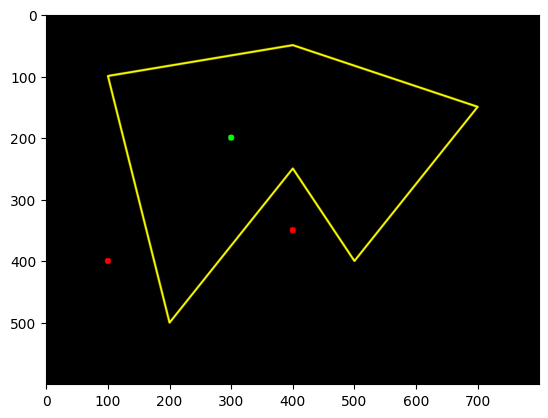

In [54]:

# 1. 创建一张黑色背景图用于可视化 (高600, 宽800, 3通道)
image = np.zeros((600, 800, 3), dtype=np.uint8)

# 2. 定义多边形区域 (一个包含凹陷的多边形)
polygon_points = np.array([
    [100, 100],
    [400, 50],
    [700, 150],
    [500, 400],
    [400, 250], # 制造凹陷的顶点
    [200, 500]
], dtype=np.float32)

# 3. 定义一组检测点
points = np.array([
    [300, 200],
    [100, 400],
    [400, 350],
], dtype=np.float32)

# 4. 执行过滤算法
inside_indices = filter_boxes_in_polygon(points, polygon_points)
print(f"所有检测点数量: {len(points)}")
print(f"在多边形内的框的索引: {inside_indices}")

# 5. 可视化绘制
# 画出多边形 (黄色)
draw_closed_polygon(image, polygon_points, color=(0, 255, 255), thickness=2)

# 画出所有的检测框和中心点
for i, point in enumerate(points):
    center_x = int(point[0])
    center_y = int(point[1])

    # 如果在多边形内，框画绿色；在外面，框画红色
    color = (0, 255, 0) if i in inside_indices else (0, 0, 255)
    cv2.circle(image, (center_x, center_y), 5, color, -1) # 画实心中心点

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
